<a href="https://colab.research.google.com/github/gabriel-tfg/Practica2_ARP/blob/main/4_2_lunarlander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Instalación

In [ ]:
!pip install -q swig
!pip install -q "gymnasium[box2d]" stable_baselines3 opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.4 MB/s eta 0:00:00


2) Librerías

In [ ]:
import os
import cv2
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
from IPython.display import HTML
from base64 import b64encode

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


3) Comprobar entorno LunarLander

In [ ]:
def get_lunarlander_env_id():
    """
    Algunas versiones de Gymnasium usan LunarLander-v3.
    Otras pueden seguir usando LunarLander-v2.
    Esta función prueba ambas para evitar errores.
    """
    for env_id in ["LunarLander-v3", "LunarLander-v2"]:
        try:
            env = gym.make(env_id)
            env.close()
            return env_id
        except Exception:
            pass
    raise ValueError("No se ha encontrado LunarLander. Revisa la instalación de gymnasium[box2d].")

ENV_ID = get_lunarlander_env_id()
print("Entorno utilizado:", ENV_ID)

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Entorno utilizado: LunarLander-v3


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

4) Descripción básica del entorno

In [ ]:
env = gym.make(ENV_ID)

print("Espacio de observaciones:", env.observation_space)
print("Espacio de acciones:", env.action_space)
print("Número de acciones:", env.action_space.n)

env.close()

Espacio de observaciones: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Espacio de acciones: Discrete(4)
Número de acciones: 4


5) Funciones auxiliares

In [ ]:
def make_train_env():
    env = gym.make(ENV_ID)
    env = Monitor(env)
    return env

def make_eval_env():
    env = gym.make(ENV_ID)
    env = Monitor(env)
    return env

def train_model(model_name, model_class, policy, hyperparams, total_timesteps=200_000):
    """
    Entrena un modelo de SB3 y guarda evaluaciones periódicas.
    """
    log_dir = f"logs/{model_name}"
    os.makedirs(log_dir, exist_ok=True)

    train_env = DummyVecEnv([make_train_env])
    eval_env = make_eval_env()

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=log_dir,
        log_path=log_dir,
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True,
        render=False
    )

    model = model_class(
        policy,
        train_env,
        verbose=1,
        **hyperparams
    )

    model.learn(
        total_timesteps=total_timesteps,
        callback=eval_callback
    )

    model.save(f"{model_name}_lunarlander")

    eval_env.close()
    train_env.close()

    return model


def evaluate_model(model, model_name, n_eval_episodes=20):
    """
    Evalúa un modelo ya entrenado.
    """
    eval_env = make_eval_env()

    mean_reward, std_reward = evaluate_policy(
        model,
        eval_env,
        n_eval_episodes=n_eval_episodes,
        deterministic=True
    )

    print(f"{model_name}")
    print("Recompensa media:", mean_reward)
    print("Desviación típica:", std_reward)

    eval_env.close()

    return mean_reward, std_reward


def episode_rewards(model, model_name, n_episodes=10):
    """
    Muestra la recompensa total obtenida episodio por episodio.
    """
    env = gym.make(ENV_ID)

    rewards = []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=42 + ep)
        terminated = False
        truncated = False
        total_reward = 0

        while not (terminated or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward

        rewards.append(total_reward)
        print(f"{model_name} - Episodio {ep+1}: {total_reward:.2f}")

    env.close()
    return rewards

6) Hiperparámetros

In [ ]:
TOTAL_TIMESTEPS = 200_000

dqn_params = {
    "learning_rate": 1e-4,
    "buffer_size": 100_000,
    "learning_starts": 10_000,
    "batch_size": 64,
    "gamma": 0.99,
    "train_freq": 4,
    "target_update_interval": 1_000,
    "exploration_fraction": 0.2,
    "exploration_final_eps": 0.05,
    "policy_kwargs": dict(net_arch=[256, 256])
}

ppo_params = {
    "learning_rate": 3e-4,
    "n_steps": 2048,
    "batch_size": 64,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.01,
    "policy_kwargs": dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])
}

a2c_params = {
    "learning_rate": 7e-4,
    "n_steps": 5,
    "gamma": 0.99,
    "gae_lambda": 1.0,
    "ent_coef": 0.01,
    "policy_kwargs": dict(net_arch=[256, 256])
}

7) Entreno DQN

In [ ]:
model_dqn = train_model(
    model_name="DQN",
    model_class=DQN,
    policy="MlpPolicy",
    hyperparams=dqn_params,
    total_timesteps=TOTAL_TIMESTEPS
)

Using cpu device
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 89.8     |
|    ep_rew_mean      | -145     |
|    exploration_rate | 0.991    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5875     |
|    time_elapsed     | 0        |
|    total_timesteps  | 359      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 102      |
|    ep_rew_mean      | -137     |
|    exploration_rate | 0.981    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5930     |
|    time_elapsed     | 0        |
|    total_timesteps  | 818      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.3     |
|    ep_rew_mean      | -123     |
|    exploration_rate | 0.974    |
| time/               |          |
|  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.1     |
|    ep_rew_mean      | -133     |
|    exploration_rate | 0.964    |
| time/               |          |
|    episodes         | 16       |
|    fps              | 4933     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1522     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.5     |
|    ep_rew_mean      | -151     |
|    exploration_rate | 0.954    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 5061     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1931     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.8     |
|    ep_rew_mean      | -154     |
|    exploration_rate | 0.945    |
| time/               |          |
|    episodes       

8) Entreno PPO

In [ ]:
model_ppo = train_model(
    model_name="PPO",
    model_class=PPO,
    policy="MlpPolicy",
    hyperparams=ppo_params,
    total_timesteps=TOTAL_TIMESTEPS
)

Using cpu device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 88.3     |
|    ep_rew_mean     | -181     |
| time/              |          |
|    fps             | 1050     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 88.2        |
|    ep_rew_mean          | -167        |
| time/                   |             |
|    fps                  | 624         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.008899662 |
|    clip_fraction        | 0.0786      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | -0.00388    |
|    learning_rate        | 0.

9) Entreno A2C

In [ ]:
model_a2c = train_model(
    model_name="A2C",
    model_class=A2C,
    policy="MlpPolicy",
    hyperparams=a2c_params,
    total_timesteps=TOTAL_TIMESTEPS
)

Se han truncado las últimas 5000 líneas del flujo de salida.
| rollout/              |          |
|    ep_len_mean        | 382      |
|    ep_rew_mean        | -48.9    |
| time/                 |          |
|    fps                | 452      |
|    iterations         | 11500    |
|    time_elapsed       | 127      |
|    total_timesteps    | 57500    |
| train/                |          |
|    entropy_loss       | -0.552   |
|    explained_variance | 0.442    |
|    learning_rate      | 0.0007   |
|    n_updates          | 11499    |
|    policy_loss        | -0.114   |
|    value_loss         | 0.811    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 391      |
|    ep_rew_mean        | -49      |
| time/                 |          |
|    fps                | 453      |
|    iterations         | 11600    |
|    time_elapsed       | 128      |
|    total_timesteps    | 58000    |
| train/      

10) Evaluación global

In [ ]:
results = []

for name, model in [
    ("DQN", model_dqn),
    ("PPO", model_ppo),
    ("A2C", model_a2c)
]:
    mean_reward, std_reward = evaluate_model(model, name, n_eval_episodes=20)
    results.append({
        "Algoritmo": name,
        "Recompensa media": mean_reward,
        "Desviación típica": std_reward
    })

results_df = pd.DataFrame(results)
results_df

DQN
Recompensa media: -4.017382700000001
Desviación típica: 18.023052612812563
PPO
Recompensa media: 260.64701305000006
Desviación típica: 21.102306211636577
A2C
Recompensa media: 12.557011750000001
Desviación típica: 119.62827208513411


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Algoritmo,Recompensa media,Desviación típica
0,DQN,-4.017383,18.023053
1,PPO,260.647013,21.102306
2,A2C,12.557012,119.628272


11) Evaluación episodio por episodio

In [ ]:
rewards_dqn = episode_rewards(model_dqn, "DQN", n_episodes=10)
rewards_ppo = episode_rewards(model_ppo, "PPO", n_episodes=10)
rewards_a2c = episode_rewards(model_a2c, "A2C", n_episodes=10)

DQN - Episodio 1: -2.97
DQN - Episodio 2: -8.81
DQN - Episodio 3: 23.31
DQN - Episodio 4: -15.01
DQN - Episodio 5: 2.59
DQN - Episodio 6: -28.30
DQN - Episodio 7: -45.83
DQN - Episodio 8: -28.96
DQN - Episodio 9: -17.57
DQN - Episodio 10: -17.87
PPO - Episodio 1: 241.77
PPO - Episodio 2: -96.22
PPO - Episodio 3: 292.13
PPO - Episodio 4: 250.72
PPO - Episodio 5: 287.60
PPO - Episodio 6: 248.89
PPO - Episodio 7: 238.33
PPO - Episodio 8: 239.92
PPO - Episodio 9: 259.20
PPO - Episodio 10: 192.91
A2C - Episodio 1: -134.15
A2C - Episodio 2: -182.02
A2C - Episodio 3: -63.34
A2C - Episodio 4: 173.30
A2C - Episodio 5: 153.56
A2C - Episodio 6: 158.78
A2C - Episodio 7: 137.03
A2C - Episodio 8: 116.07
A2C - Episodio 9: 149.25
A2C - Episodio 10: -75.08


12) Tabla comparativa

In [ ]:
episode_df = pd.DataFrame({
    "Episodio": np.arange(1, 11),
    "DQN": rewards_dqn,
    "PPO": rewards_ppo,
    "A2C": rewards_a2c
})

episode_df

,Episodio,DQN,PPO,A2C
0,1,-2.970523,241.772197,-134.149519
1,2,-8.814608,-96.222047,-182.024058
2,3,23.306819,292.126124,-63.336645
3,4,-15.008142,250.723770,173.303125
4,5,2.586873,287.597642,153.556700
5,6,-28.299159,248.885813,158.780505
6,7,-45.831142,238.329752,137.027699
7,8,-28.963107,239.922729,116.067526
8,9,-17.569537,259.198358,149.245926
9,10,-17.868044,192.914435,-75.077166


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


13) Gráfica de comparación por episodios

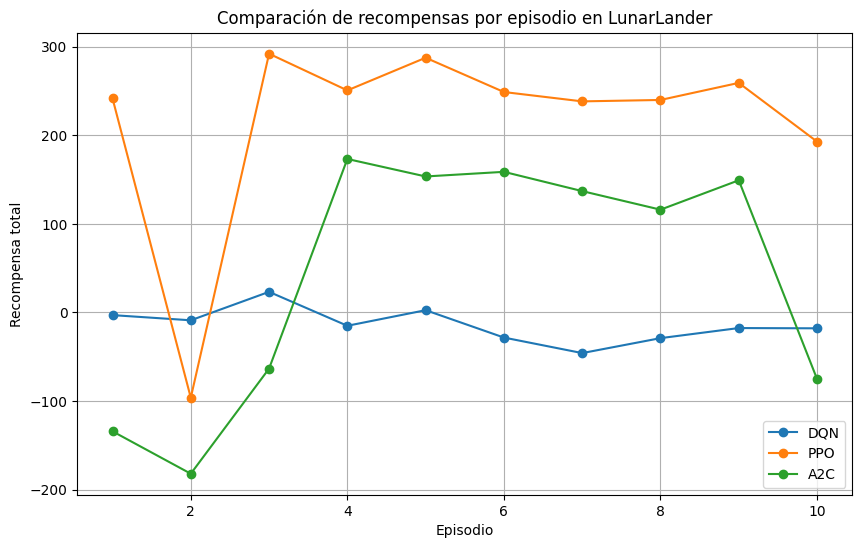

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(episode_df["Episodio"], episode_df["DQN"], marker="o", label="DQN")
plt.plot(episode_df["Episodio"], episode_df["PPO"], marker="o", label="PPO")
plt.plot(episode_df["Episodio"], episode_df["A2C"], marker="o", label="A2C")

plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("Comparación de recompensas por episodio en LunarLander")
plt.legend()
plt.grid(True)
plt.show()

14) Evaluación del entrenamiento

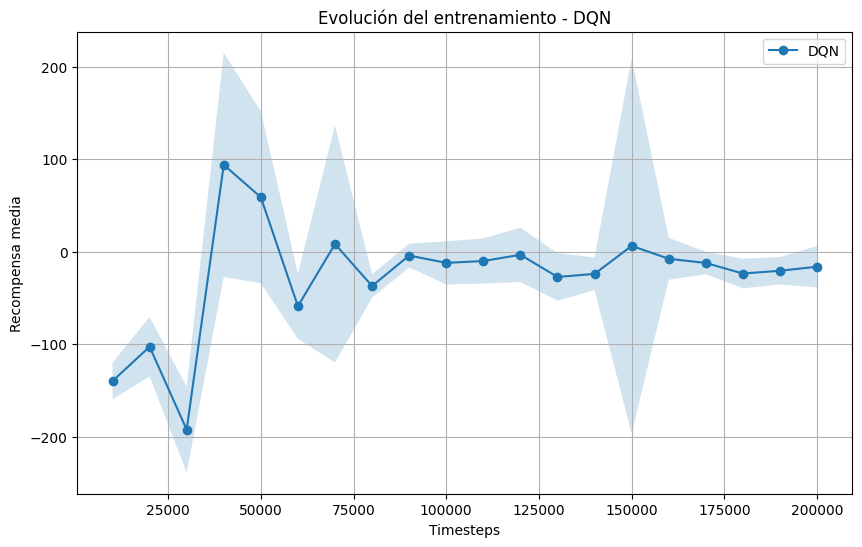

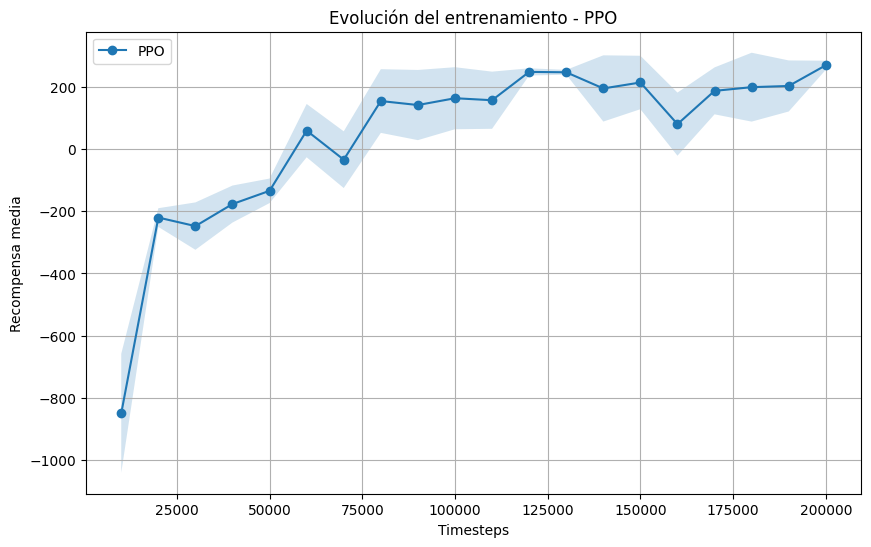

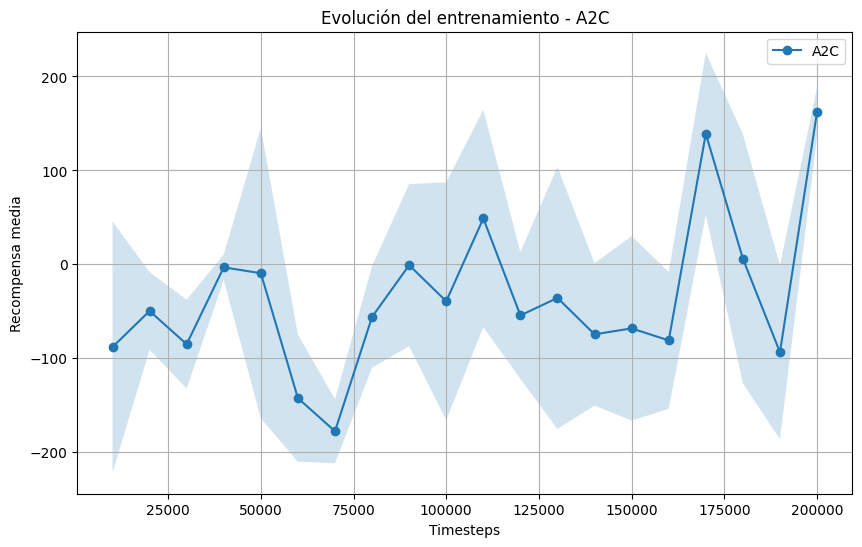

In [ ]:
def plot_training_curve(model_name):
    eval_path = f"logs/{model_name}/evaluations.npz"

    if not os.path.exists(eval_path):
        print(f"No existe archivo de evaluación para {model_name}")
        return

    data = np.load(eval_path)
    timesteps = data["timesteps"]
    results = data["results"]

    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, marker="o", label=f"{model_name}")
    plt.fill_between(
        timesteps,
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.2
    )

    plt.xlabel("Timesteps")
    plt.ylabel("Recompensa media")
    plt.title(f"Evolución del entrenamiento - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_curve("DQN")
plot_training_curve("PPO")
plot_training_curve("A2C")

15) Elegir mejor modelo

In [ ]:
best_row = results_df.loc[results_df["Recompensa media"].idxmax()]
best_model_name = best_row["Algoritmo"]

print("Mejor algoritmo:", best_model_name)
print(best_row)

if best_model_name == "DQN":
    best_model = model_dqn
elif best_model_name == "PPO":
    best_model = model_ppo
else:
    best_model = model_a2c

Mejor algoritmo: PPO
Algoritmo                   PPO
Recompensa media     260.647013
Desviación típica     21.102306
Name: 1, dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


16) Generar vídeo del mejor modelo

In [ ]:
def save_video(model, filename="lunarlander_best_model.mp4", seed=42):
    env = gym.make(ENV_ID, render_mode="rgb_array")

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    frames = []
    total_reward = 0

    while not (terminated or truncated):
        frame = env.render()
        frames.append(frame)

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

    env.close()

    height, width, _ = frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    video = cv2.VideoWriter(filename, fourcc, 30.0, (width, height))

    for frame in frames:
        video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    video.release()

    print(f"Vídeo guardado como {filename}")
    print(f"Recompensa total del episodio: {total_reward:.2f}")

    return filename


video_path = save_video(best_model, filename="lunarlander_best_model.mp4")

Vídeo guardado como lunarlander_best_model.mp4
Recompensa total del episodio: 241.77


17) Visualizar vídeo

In [ ]:
compressed_path = "lunarlander_best_model_compressed.mp4"

os.system(f"ffmpeg -y -i {video_path} -vcodec libx264 {compressed_path}")

mp4 = open(compressed_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=800 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

18) Guardar tabla de resultados

In [ ]:
results_df.to_csv("lunarlander_results_summary.csv", index=False)
episode_df.to_csv("lunarlander_episode_rewards.csv", index=False)

print("Tablas guardadas correctamente.")

Tablas guardadas correctamente.
